# Lab 4: Perceptron Multicapa (MLP) para Clasificacion de Digitos

En el Lab 3 clasificamos digitos MNIST con **Regresion Logistica** (modelo lineal) y alcanzamos ~92% de accuracy.
Hoy damos el salto a modelos **no lineales**: el Perceptron Multicapa (MLP).

Un MLP agrega **capas ocultas** con funciones de activacion no lineales entre la entrada y la salida,
lo que le permite aprender fronteras de decision mucho mas complejas que un hiperplano.

### Objetivos de aprendizaje

- Entender la diferencia entre un modelo lineal y un MLP.
- Construir y entrenar MLPs en PyTorch.
- Comparar el efecto de la **profundidad** (1 vs 2 capas ocultas).
- Comparar **funciones de activacion** (ReLU vs Sigmoid).
- Comparar **funciones de perdida** (CrossEntropy vs BCE por clase).
- Aplicar lo aprendido al proyecto semestral.

### Ruta del laboratorio

1. Setup y carga de MNIST.
2. Baseline lineal (equivalente a Regresion Logistica).
3. MLP con 2 capas ocultas (256 → 128 → 10).
4. Efecto de la profundidad: 1 capa oculta vs 2.
5. Funciones de activacion: ReLU vs Sigmoid.
6. Funciones de perdida: CrossEntropy vs BCE por clase.
7. Resumen comparativo.
8. Aplicacion al proyecto.

## 1) Setup y carga de MNIST

In [ ]:
import torch
from torch import nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

torch.manual_seed(42)
np.random.seed(42)
sns.set_style("whitegrid")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
])

train_ds = datasets.MNIST(root="./data", train=True,  download=True, transform=transform)
test_ds  = datasets.MNIST(root="./data", train=False, download=True, transform=transform)

BATCH_SIZE = 128
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print(f"Train: {len(train_ds)} imagenes | Test: {len(test_ds)} imagenes")
print(f"Ejemplo — imagen shape: {train_ds[0][0].shape}, label: {train_ds[0][1]}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 20.2MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 500kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.72MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.89MB/s]

Train: 60000 imagenes | Test: 10000 imagenes
Ejemplo — imagen shape: torch.Size([1, 28, 28]), label: 5


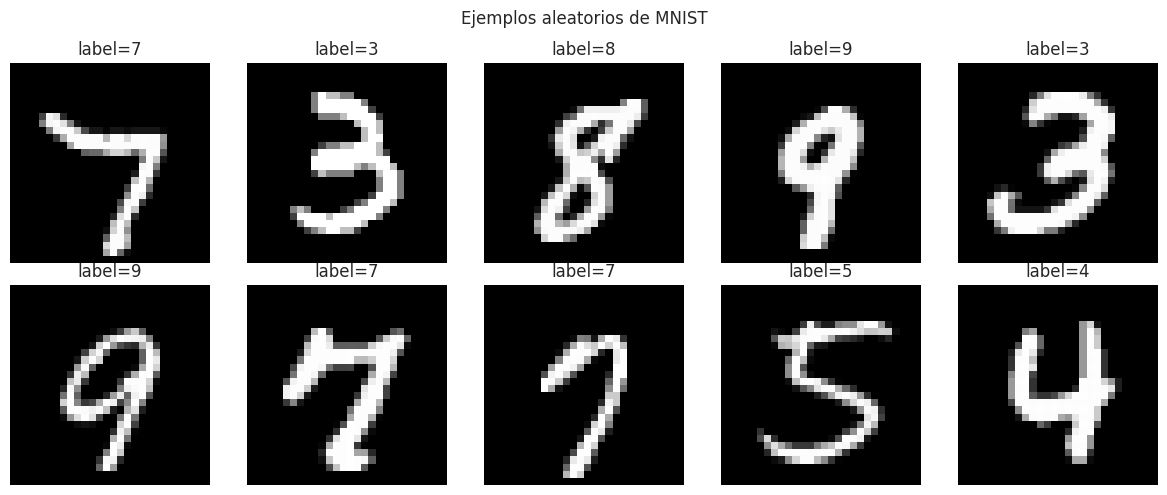

In [ ]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
idx = np.random.choice(len(train_ds), size=10, replace=False)
for ax, i in zip(axes.ravel(), idx):
    img, label = train_ds[i]
    ax.imshow(img.squeeze().numpy(), cmap="gray")
    ax.set_title(f"label={label}")
    ax.axis("off")
plt.suptitle("Ejemplos aleatorios de MNIST")
plt.tight_layout()
plt.show()

## 2) Baseline lineal (Softmax = Regresion Logistica)

Antes de construir un MLP, entrenamos un **modelo lineal** en PyTorch como punto de referencia.
Este modelo es matematicamente equivalente a la Regresion Logistica Multinomial que usamos en Lab 3 con sklearn.

Arquitectura: **784 → 10** (sin capas ocultas).

Esperamos obtener ~92% accuracy, similar a lo que vimos con sklearn.

In [ ]:
class SoftmaxLinear(nn.Module):
    """Modelo lineal: equivalente a Regresion Logistica Multinomial."""
    def __init__(self, input_dim=28*28, num_classes=10):
        super().__init__()
        self.flatten = nn.Flatten()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x):
        x = self.flatten(x)
        return self.fc(x)  # logits (softmax implicito en CrossEntropyLoss)

In [ ]:
def run_epoch(dl, model, criterion, optimizer=None):
    """Ejecuta una epoca de entrenamiento o evaluacion.
    Si optimizer es None, se ejecuta en modo evaluacion (sin backward)."""
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = criterion(logits, y)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(1) == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total

In [ ]:
def train_model(model, train_loader, test_loader, criterion, optimizer, epochs=15, label="Modelo"):
    """Entrena un modelo y retorna el historial de loss y accuracy por epoca."""
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for ep in range(epochs):
        tr_loss, tr_acc = run_epoch(train_loader, model, criterion, optimizer)
        te_loss, te_acc = run_epoch(test_loader, model, criterion, optimizer=None)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"[{label}] Epoch {ep+1:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f}  acc {tr_acc:.4f} | "
                  f"test loss {te_loss:.4f}  acc {te_acc:.4f}")

    print(f"\n[{label}] Accuracy final en test: {history['test_acc'][-1]:.4f}")
    return history

In [ ]:
baseline = SoftmaxLinear().to(device)
criterion_ce = nn.CrossEntropyLoss()
optimizer_baseline = torch.optim.SGD(baseline.parameters(), lr=0.1)

hist_baseline = train_model(
    baseline, train_loader, test_loader,
    criterion_ce, optimizer_baseline,
    epochs=15, label="Baseline lineal"
)

[Baseline lineal] Epoch 01/15 | train loss 0.3725  acc 0.8913 | test loss 0.2957  acc 0.9158
[Baseline lineal] Epoch 05/15 | train loss 0.2782  acc 0.9213 | test loss 0.2757  acc 0.9207
[Baseline lineal] Epoch 10/15 | train loss 0.2675  acc 0.9262 | test loss 0.2795  acc 0.9232
[Baseline lineal] Epoch 15/15 | train loss 0.2603  acc 0.9274 | test loss 0.2808  acc 0.9203

[Baseline lineal] Accuracy final en test: 0.9203


## 3) MLP con 2 capas ocultas

Ahora agregamos **capas ocultas** con funciones de activacion no lineales.
Esto permite al modelo aprender representaciones intermedias y fronteras de decision curvas.

Arquitectura (sugerida por el profesor):

$$
\text{Input }(784) \;\rightarrow\; \text{Oculta}_1(256) + \text{ReLU} \;\rightarrow\; \text{Oculta}_2(128) + \text{ReLU} \;\rightarrow\; \text{Salida }(10)
$$

**¿Por que funciona mejor?** Cada capa oculta aprende a detectar patrones de complejidad creciente:
la primera puede detectar bordes y trazos simples; la segunda combina esos patrones en partes de digitos.

In [ ]:
def act_fn(name: str):
    """Factory de funciones de activacion."""
    name = name.lower()
    if name == "relu":    return nn.ReLU()
    if name == "sigmoid": return nn.Sigmoid()
    if name == "tanh":    return nn.Tanh()
    raise ValueError(f"Activacion no soportada: {name}")


class MLP(nn.Module):
    """Perceptron Multicapa configurable.

    Args:
        in_dim:      dimensionalidad de la entrada (784 para MNIST aplanado).
        hidden_dims: lista con el numero de neuronas de cada capa oculta, e.g. [256, 128].
        out_dim:     numero de clases de salida (10 para MNIST).
        act:         nombre de la activacion para capas ocultas ('relu', 'sigmoid', 'tanh').
    """
    def __init__(self, in_dim, hidden_dims, out_dim, act="relu"):
        super().__init__()
        self.flatten = nn.Flatten()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev, h), act_fn(act)]
            prev = h
        layers += [nn.Linear(prev, out_dim)]
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        x = self.flatten(x)
        return self.net(x)

In [ ]:
mlp_2h = MLP(784, [256, 128], 10, act="relu").to(device)
opt_2h = torch.optim.Adam(mlp_2h.parameters(), lr=1e-3)

print(mlp_2h)
n_params_2h = sum(p.numel() for p in mlp_2h.parameters())
print(f"\nParametros totales: {n_params_2h:,}")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)

Parametros totales: 235,146


In [ ]:
hist_2h = train_model(
    mlp_2h, train_loader, test_loader,
    criterion_ce, opt_2h,
    epochs=15, label="MLP 2 capas (ReLU)"
)

[MLP 2 capas (ReLU)] Epoch 01/15 | train loss 0.2660  acc 0.9233 | test loss 0.1226  acc 0.9624
[MLP 2 capas (ReLU)] Epoch 05/15 | train loss 0.0377  acc 0.9878 | test loss 0.0893  acc 0.9742
[MLP 2 capas (ReLU)] Epoch 10/15 | train loss 0.0201  acc 0.9930 | test loss 0.0734  acc 0.9808
[MLP 2 capas (ReLU)] Epoch 15/15 | train loss 0.0112  acc 0.9963 | test loss 0.0884  acc 0.9811

[MLP 2 capas (ReLU)] Accuracy final en test: 0.9811


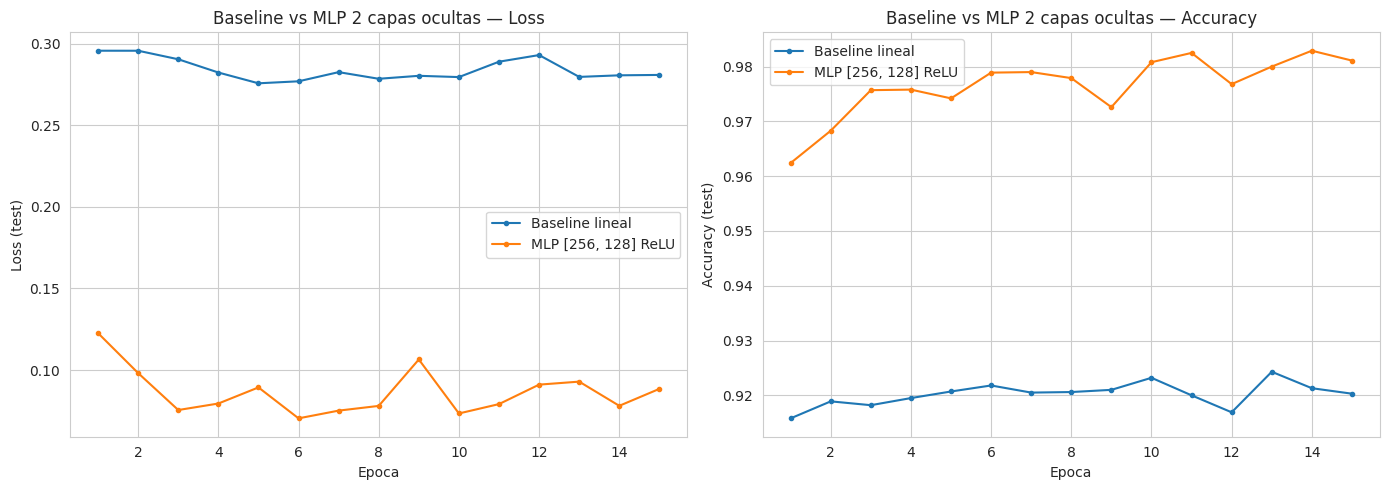

In [ ]:
def plot_history(histories, labels, title="Entrenamiento"):
    """Grafica loss y accuracy de multiples modelos."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for hist, lbl in zip(histories, labels):
        epochs = range(1, len(hist["train_loss"]) + 1)
        axes[0].plot(epochs, hist["test_loss"], marker="o", markersize=3, label=lbl)
        axes[1].plot(epochs, hist["test_acc"],  marker="o", markersize=3, label=lbl)

    axes[0].set_xlabel("Epoca")
    axes[0].set_ylabel("Loss (test)")
    axes[0].set_title(f"{title} — Loss")
    axes[0].legend()

    axes[1].set_xlabel("Epoca")
    axes[1].set_ylabel("Accuracy (test)")
    axes[1].set_title(f"{title} — Accuracy")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


plot_history(
    [hist_baseline, hist_2h],
    ["Baseline lineal", "MLP [256, 128] ReLU"],
    title="Baseline vs MLP 2 capas ocultas"
)

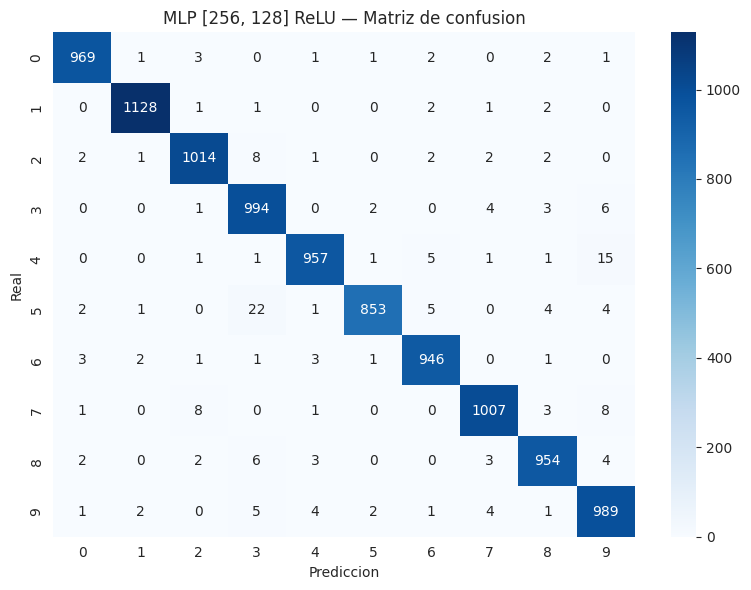

In [ ]:
def plot_confusion(model, test_loader, title="Matriz de confusion"):
    """Genera predicciones y muestra la matriz de confusion."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for x, y in test_loader:
            x = x.to(device)
            preds = model(x).argmax(1).cpu()
            all_preds.append(preds)
            all_labels.append(y)

    all_preds = torch.cat(all_preds).numpy()
    all_labels = torch.cat(all_labels).numpy()

    cm = confusion_matrix(all_labels, all_preds)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Prediccion")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    return all_preds, all_labels


preds_2h, labels_2h = plot_confusion(mlp_2h, test_loader, "MLP [256, 128] ReLU — Matriz de confusion")

## 4) Efecto de la profundidad: 1 capa oculta vs 2

¿Es realmente necesario tener 2 capas ocultas para MNIST?

Entrenamos una MLP con **una sola capa oculta** (784 → 256 → 10) y comparamos.

Hipotesis: con una capa oculta el modelo tiene menos capacidad representacional,
pero podria ser suficiente para un problema como MNIST que no es extremadamente complejo.

In [ ]:
mlp_1h = MLP(784, [256], 10, act="relu").to(device)
opt_1h = torch.optim.Adam(mlp_1h.parameters(), lr=1e-3)

print(mlp_1h)
n_params_1h = sum(p.numel() for p in mlp_1h.parameters())
print(f"\nParametros totales: {n_params_1h:,}")
print(f"(MLP 2 capas tiene {n_params_2h:,} parametros)")

MLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (net): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=10, bias=True)
  )
)

Parametros totales: 203,530
(MLP 2 capas tiene 235,146 parametros)


In [ ]:
hist_1h = train_model(
    mlp_1h, train_loader, test_loader,
    criterion_ce, opt_1h,
    epochs=15, label="MLP 1 capa (ReLU)"
)

[MLP 1 capa (ReLU)] Epoch 01/15 | train loss 0.2700  acc 0.9218 | test loss 0.1373  acc 0.9600
[MLP 1 capa (ReLU)] Epoch 05/15 | train loss 0.0396  acc 0.9878 | test loss 0.0796  acc 0.9764
[MLP 1 capa (ReLU)] Epoch 10/15 | train loss 0.0134  acc 0.9959 | test loss 0.0754  acc 0.9810
[MLP 1 capa (ReLU)] Epoch 15/15 | train loss 0.0089  acc 0.9971 | test loss 0.0860  acc 0.9801

[MLP 1 capa (ReLU)] Accuracy final en test: 0.9801


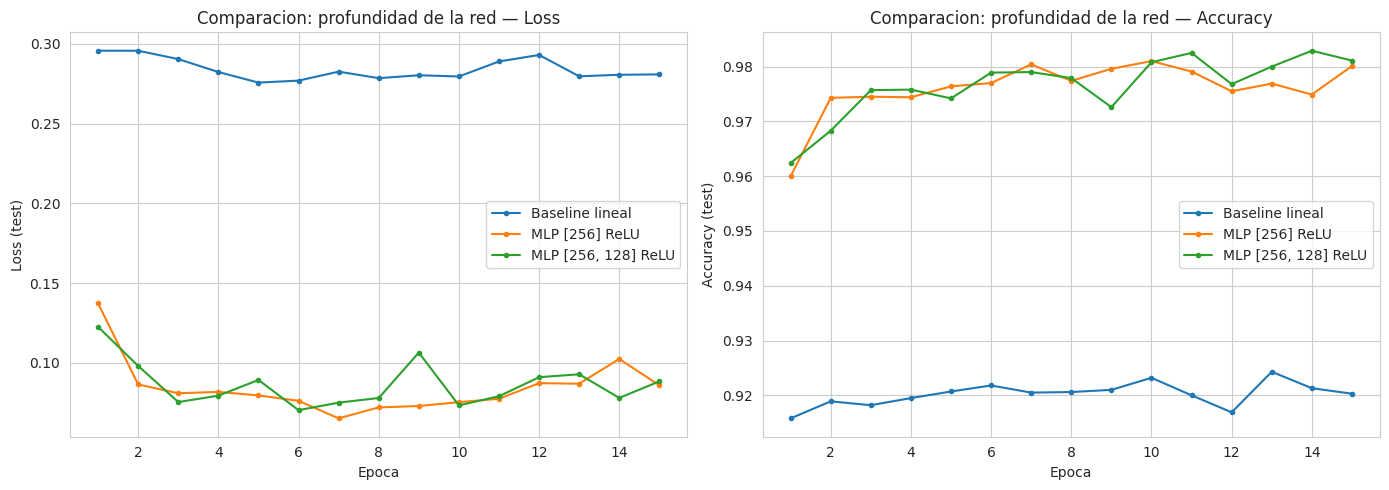

  Baseline lineal  — accuracy test: 0.9203
  MLP 1 capa [256] — accuracy test: 0.9801  (203,530 params)
  MLP 2 capas [256,128] — accuracy test: 0.9811  (235,146 params)


In [ ]:
plot_history(
    [hist_baseline, hist_1h, hist_2h],
    ["Baseline lineal", "MLP [256] ReLU", "MLP [256, 128] ReLU"],
    title="Comparacion: profundidad de la red"
)

print(f"  Baseline lineal  — accuracy test: {hist_baseline['test_acc'][-1]:.4f}")
print(f"  MLP 1 capa [256] — accuracy test: {hist_1h['test_acc'][-1]:.4f}  ({n_params_1h:,} params)")
print(f"  MLP 2 capas [256,128] — accuracy test: {hist_2h['test_acc'][-1]:.4f}  ({n_params_2h:,} params)")

### Discusion: profundidad

**Preguntas para reflexionar:**

- ¿La diferencia entre 1 y 2 capas ocultas es grande en MNIST?
- ¿Cuantos parametros extra agrega la segunda capa? ¿Vale la pena?
- ¿En que tipo de problemas esperarias que mas profundidad ayude significativamente?

> En MNIST la diferencia es practicamente nula (e incluso 1 capa puede ganarle a 2).
> MNIST es un problema relativamente simple donde una sola capa oculta ya captura los patrones necesarios.
> Sin embargo, en problemas mas complejos (imagenes a color, texto, datos con interacciones complejas)
> la profundidad adicional permite aprender jerarquias de features mas ricas.

## 5) Funciones de activacion: ReLU vs Sigmoid

Usamos la MLP de 1 capa oculta [256] para aislar el efecto de la activacion sin el costo extra de 2 capas.

La funcion de activacion determina como se propaga la informacion y el gradiente a traves de la red.

| Activacion | Formula | Rango | Gradiente |
|---|---|---|---|
| **ReLU** | $\max(0, x)$ | $[0, \infty)$ | 1 si $x > 0$, 0 si $x < 0$ |
| **Sigmoid** | $\frac{1}{1+e^{-x}}$ | $(0, 1)$ | Maximo 0.25, se **satura** en extremos |

**Problema del gradiente desvaneciente (vanishing gradient):**
La derivada de Sigmoid es como maximo 0.25 y tiende a 0 cuando la entrada es muy positiva o negativa.
Al multiplicar gradientes capa por capa (regla de la cadena / backpropagation),
los gradientes se hacen exponencialmente mas pequenos en las capas iniciales → el aprendizaje se estanca.


ReLU no sufre este problema para entradas positivas (gradiente = 1), por eso es la activacionpor defecto en redes modernas.

In [ ]:
mlp_sigmoid = MLP(784, [256], 10, act="sigmoid").to(device)
opt_sigmoid = torch.optim.Adam(mlp_sigmoid.parameters(), lr=1e-3)

hist_sigmoid = train_model(
    mlp_sigmoid, train_loader, test_loader,
    criterion_ce, opt_sigmoid,
    epochs=15, label="MLP 1 capa (Sigmoid)"
)

[MLP 1 capa (Sigmoid)] Epoch 01/15 | train loss 0.4149  acc 0.8906 | test loss 0.2219  acc 0.9354
[MLP 1 capa (Sigmoid)] Epoch 05/15 | train loss 0.0793  acc 0.9787 | test loss 0.0910  acc 0.9723
[MLP 1 capa (Sigmoid)] Epoch 10/15 | train loss 0.0274  acc 0.9943 | test loss 0.0691  acc 0.9776
[MLP 1 capa (Sigmoid)] Epoch 15/15 | train loss 0.0091  acc 0.9991 | test loss 0.0662  acc 0.9804

[MLP 1 capa (Sigmoid)] Accuracy final en test: 0.9804


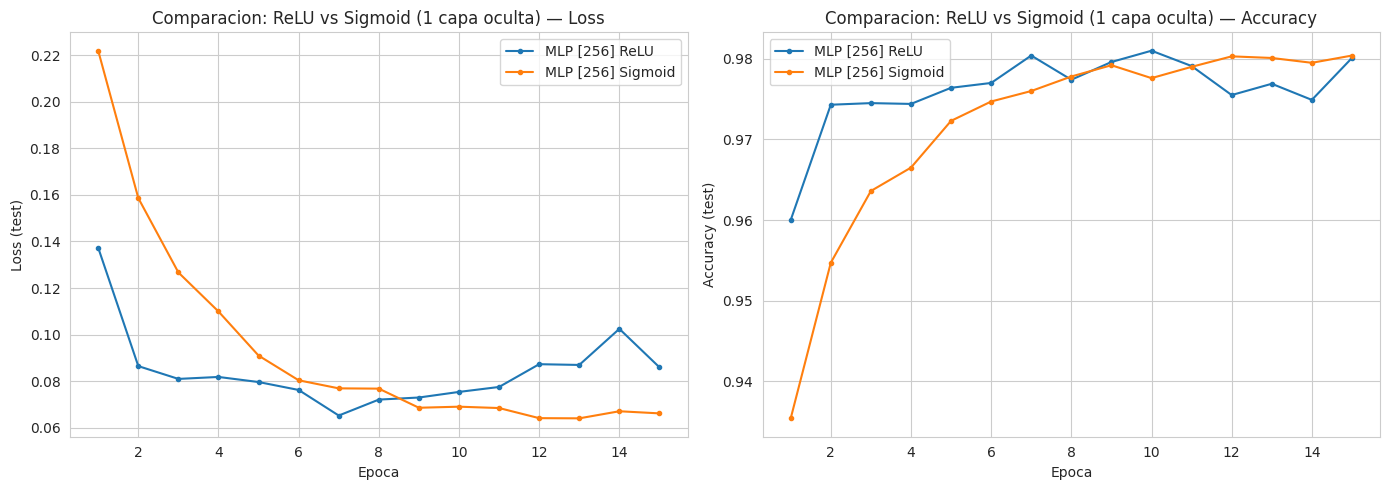

  MLP [256] ReLU    — accuracy test: 0.9801
  MLP [256] Sigmoid — accuracy test: 0.9804


In [ ]:
plot_history(
    [hist_1h, hist_sigmoid],
    ["MLP [256] ReLU", "MLP [256] Sigmoid"],
    title="Comparacion: ReLU vs Sigmoid (1 capa oculta)"
)

print(f"  MLP [256] ReLU    — accuracy test: {hist_1h['test_acc'][-1]:.4f}")
print(f"  MLP [256] Sigmoid — accuracy test: {hist_sigmoid['test_acc'][-1]:.4f}")

### Discusion: funciones de activacion

**Observaciones:**

- ReLU converge **mas rapido** en las primeras epocas (observa la diferencia en accuracy en epoca 1-3).
- Sigmoid arranca con loss mas alto y accuracy mas baja, pero puede acercarse eventualmente.
- Con mas capas ocultas, la brecha seria aun mayor porque el vanishing gradient se acumula.

**Conclusion practica:** usa ReLU como activacion por defecto en capas ocultas. Sigmoid se reserva para
la capa de salida cuando necesitas probabilidades independientes (e.g., clasificacion binaria o multi-label).

## 6) Funciones de perdida: CrossEntropy vs BCE por clase

Hasta ahora hemos usado `nn.CrossEntropyLoss` (CE), que internamente aplica **Softmax** sobre los logits
y calcula la cross-entropy contra la clase verdadera. Esto asume que las clases son **mutuamente excluyentes**
(cada imagen es exactamente un digito).

Una alternativa es usar `nn.BCEWithLogitsLoss` (BCE), que aplica **Sigmoid** independientemente
a cada neurona de salida. Para esto, las etiquetas deben estar en formato **one-hot**
(vector de tamaño 10 con un 1 en la posicion de la clase verdadera y 0 en el resto).

Esto equivale a entrenar **10 clasificadores binarios independientes**, uno por clase.

| Aspecto | CrossEntropy (CE) | BCE por clase |
|---|---|---|
| Activacion salida | Softmax (implicito) | Sigmoid (por neurona) |
| Etiquetas | Indice de clase (entero) | One-hot (vector float) |
| Supuesto | Clases mutuamente excluyentes | Clases independientes |
| Caso de uso tipico | Multiclase estandar | Multi-label (o experimentacion) |

In [ ]:
def run_epoch_bce(dl, model, criterion_bce, optimizer=None, num_classes=10):
    """Epoca de entrenamiento/evaluacion usando BCEWithLogitsLoss.
    Las etiquetas se convierten a one-hot internamente."""
    if optimizer is None:
        model.eval()
    else:
        model.train()

    total_loss, total_correct, total = 0.0, 0, 0
    for x, y in dl:
        x, y = x.to(device), y.to(device)
        y_onehot = F.one_hot(y, num_classes=num_classes).float()

        logits = model(x)
        loss = criterion_bce(logits, y_onehot)

        if optimizer is not None:
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

        total_loss += loss.item() * x.size(0)
        preds = logits.argmax(1)  # argmax sobre las 10 salidas (sin softmax, no hace falta)
        total_correct += (preds == y).sum().item()
        total += x.size(0)

    return total_loss / total, total_correct / total


def train_model_bce(model, train_loader, test_loader, epochs=15, lr=1e-3, label="Modelo"):
    """Entrena un modelo con BCEWithLogitsLoss."""
    criterion_bce = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    history = {"train_loss": [], "test_loss": [], "train_acc": [], "test_acc": []}

    for ep in range(epochs):
        tr_loss, tr_acc = run_epoch_bce(train_loader, model, criterion_bce, optimizer)
        te_loss, te_acc = run_epoch_bce(test_loader, model, criterion_bce, optimizer=None)

        history["train_loss"].append(tr_loss)
        history["test_loss"].append(te_loss)
        history["train_acc"].append(tr_acc)
        history["test_acc"].append(te_acc)

        if (ep + 1) % 5 == 0 or ep == 0:
            print(f"[{label}] Epoch {ep+1:02d}/{epochs} | "
                  f"train loss {tr_loss:.4f}  acc {tr_acc:.4f} | "
                  f"test loss {te_loss:.4f}  acc {te_acc:.4f}")

    print(f"\n[{label}] Accuracy final en test: {history['test_acc'][-1]:.4f}")
    return history

In [ ]:
mlp_bce = MLP(784, [256], 10, act="relu").to(device)

hist_bce = train_model_bce(
    mlp_bce, train_loader, test_loader,
    epochs=15, lr=1e-3, label="MLP 1 capa ReLU + BCE"
)

[MLP 1 capa ReLU + BCE] Epoch 01/15 | train loss 0.0689  acc 0.8990 | test loss 0.0350  acc 0.9511
[MLP 1 capa ReLU + BCE] Epoch 05/15 | train loss 0.0136  acc 0.9825 | test loss 0.0165  acc 0.9778
[MLP 1 capa ReLU + BCE] Epoch 10/15 | train loss 0.0056  acc 0.9946 | test loss 0.0148  acc 0.9812
[MLP 1 capa ReLU + BCE] Epoch 15/15 | train loss 0.0025  acc 0.9984 | test loss 0.0155  acc 0.9820

[MLP 1 capa ReLU + BCE] Accuracy final en test: 0.9820


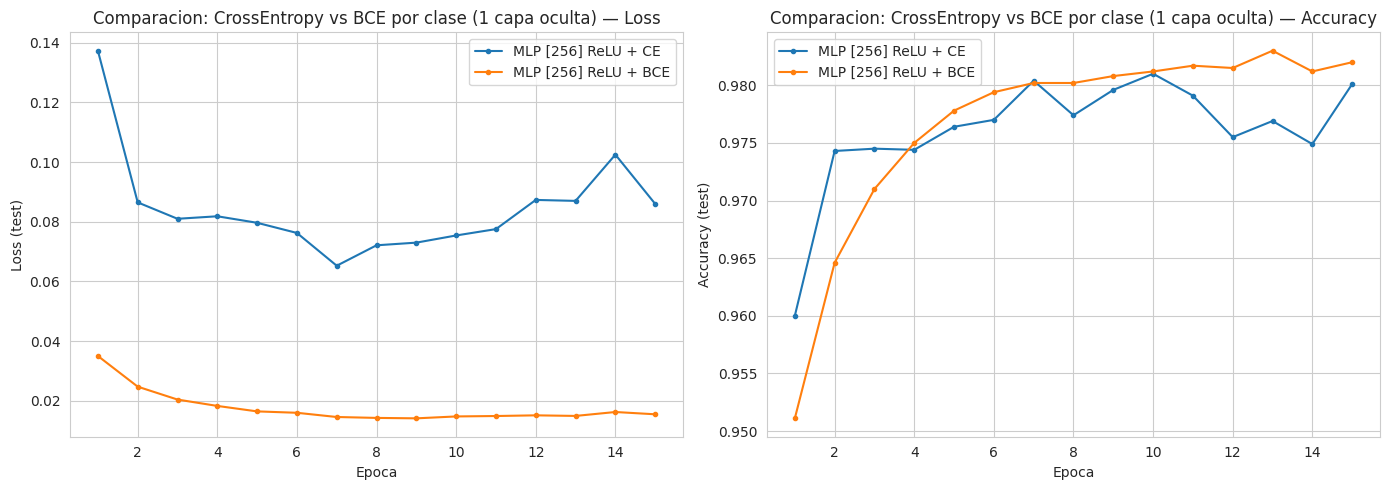

  MLP [256] + CE  — accuracy test: 0.9801
  MLP [256] + BCE — accuracy test: 0.9820


In [ ]:
plot_history(
    [hist_1h, hist_bce],
    ["MLP [256] ReLU + CE", "MLP [256] ReLU + BCE"],
    title="Comparacion: CrossEntropy vs BCE por clase (1 capa oculta)"
)

print(f"  MLP [256] + CE  — accuracy test: {hist_1h['test_acc'][-1]:.4f}")
print(f"  MLP [256] + BCE — accuracy test: {hist_bce['test_acc'][-1]:.4f}")

### Discusion: CE vs BCE

- Para problemas **multiclase mutuamente excluyentes** (como MNIST), CE es la opcion natural.
  Softmax garantiza que las probabilidades sumen 1, aprovechando la estructura del problema.
- BCE trata cada clase de forma **independiente**. Esto es util en problemas **multi-label**
  (e.g., una imagen puede tener multiples etiquetas: "perro", "parque", "dia soleado").
- En MNIST, BCE suele funcionar razonablemente bien, pero pierde la restriccion de que las
  probabilidades sumen 1, lo que puede dificultar la calibracion.

**Conclusion practica:** usa CE para multiclase estandar, BCE para multi-label.

### Conclusiones

1. **MLP >> Modelo lineal:** La no linealidad (capas ocultas + activacion) es clave.
   El salto de ~92% a ~97%+ muestra que fronteras de decision lineales son insuficientes
   para capturar la complejidad de los digitos.

2. **1 capa ≈ 2 capas (en MNIST):** La diferencia es practicamente nula; incluso 1 capa puede
   empatar o superar a 2. MNIST no es lo suficientemente complejo para necesitar mas profundidad.
   En problemas mas dificiles, la profundidad adicional si marca diferencia.

3. **ReLU > Sigmoid (en velocidad de convergencia):** ReLU converge mas rapido en las primeras
   epocas y evita el problema del gradiente desvaneciente. Sigmoid eventualmente se acerca,
   pero necesita mas epocas.

4. **CE ≈ BCE:** Para multiclase mutuamente excluyente (MNIST), CE es la opcion natural
   y mas limpia. BCE funciona pero no aprovecha la estructura del problema.

### Puente hacia el siguiente lab

Los MLP operan sobre pixeles **aplanados** (vectores de 784 dimensiones), ignorando la estructura

espacial 2D de la imagen. En el proximo lab exploraremos **Redes Neuronales Convolucionales (CNN)**,que operan directamente sobre la imagen 2D y explotan la localidad espacial.

## 7) Ejercicio: aplica MLP a tu proyecto

Adapta la clase `MLP` y el flujo de entrenamiento a los datos de tu proyecto semestral.

**Pasos:**

1. Carga tu dataset y crea DataLoaders.
2. Define `in_dim` (numero de features de entrada) y `out_dim` (numero de clases).
3. Elige `hidden_dims` (empieza con algo simple como `[64, 32]`).
4. Entrena y evalua.
5. Experimenta con diferentes arquitecturas y compara.

In [ ]:
# ============================================================
# TODO: Adapta este template a tu proyecto
# ============================================================

# 1) Carga de datos
# X_train, X_test, y_train, y_test = ...  # tu dataset

# 2) Crear TensorDataset y DataLoaders
# from torch.utils.data import TensorDataset
# train_ds_proy = TensorDataset(torch.tensor(X_train, dtype=torch.float32),
#                                torch.tensor(y_train, dtype=torch.long))
# test_ds_proy  = TensorDataset(torch.tensor(X_test, dtype=torch.float32),
#                                torch.tensor(y_test, dtype=torch.long))
# train_dl_proy = DataLoader(train_ds_proy, batch_size=64, shuffle=True)
# test_dl_proy  = DataLoader(test_ds_proy,  batch_size=64, shuffle=False)

# 3) Definir MLP
# IN_DIM  = X_train.shape[1]  # numero de features
# OUT_DIM = len(set(y_train)) # numero de clases
# modelo_proy = MLP(IN_DIM, [64, 32], OUT_DIM, act='relu').to(device)

# 4) Entrenar
# opt_proy = torch.optim.Adam(modelo_proy.parameters(), lr=1e-3)
# hist_proy = train_model(modelo_proy, train_dl_proy, test_dl_proy,
#                          nn.CrossEntropyLoss(), opt_proy,
#                          epochs=30, label="Proyecto")

# 5) Evaluar
# plot_confusion(modelo_proy, test_dl_proy, "Proyecto — Matriz de confusion")

print("Descomenta y adapta el codigo de arriba para tu proyecto.")

Descomenta y adapta el codigo de arriba para tu proyecto.
